In [4]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as po

from sklearn.metrics import r2_score

In [7]:
x,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [8]:
df = pd.DataFrame({'Feature1':x[:,0],'Feature2':x[:,1],'Target':y})

In [9]:
df.head()

,Feature1,Feature2,Target
0,0.644604,1.580672,39.362209
1,-0.234431,0.579957,44.767565
2,0.182616,-1.133796,-51.974048
3,1.819559,-0.122412,22.836195
4,1.516576,-0.064812,-112.131740


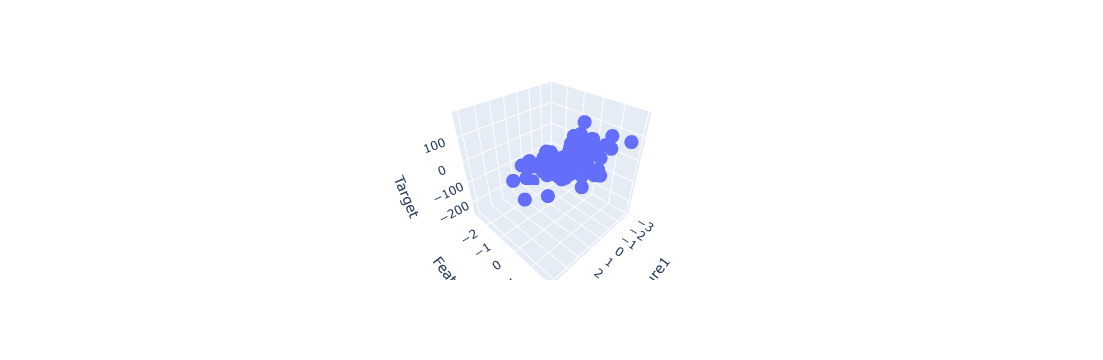

In [12]:
fig = px.scatter_3d(df, x='Feature1', y='Feature2', z='Target')
fig

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=3)

In [16]:
from sklearn.linear_model import LinearRegression

In [18]:
lr = LinearRegression()

In [19]:
lr.fit(x_train,y_train)

LinearRegression()

In [20]:
y_pred = lr.predict(x_test)

In [23]:
r2_score(y_test,y_pred)

0.7221444693692585

In [25]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

z = z_final

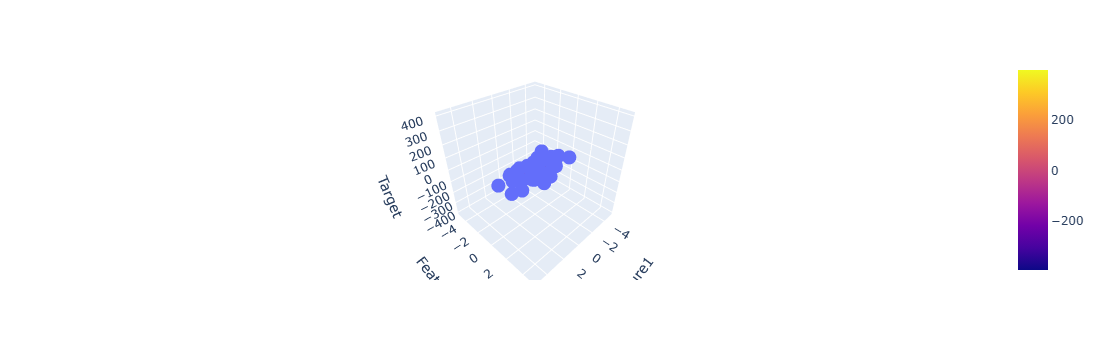

In [28]:
fig = px.scatter_3d(df, x='Feature1', y='Feature2', z='Target')

fig.add_trace(po.Surface(x = x, y = y, z =z ))

fig.show()

In [29]:
lr.coef_

array([14.92942243, 64.71648138])

In [30]:
lr.intercept_

np.float64(1.3297493865912184)